In [1]:
# ==========================================
# PHASE 1: ASK
# ==========================================
# Business Task: How do annual members and casual riders use Cyclistic bikes differently?
# Stakeholders: Lily Moreno and the Cyclistic Executive Team

In [2]:
# ==========================================
# PHASE 2: PREPARE
# ==========================================
# Data Source: Divvy Trip Data (last 12 months)
# Note: Data unzipped and stored in local directory structure

# --- Loading the Consolidated Dataset ---
# (Pre-processing step: 12 months were merged into one CSV to improve performance)
# The following code is commented out because it has already been run to create the annual dataset. If you need to recreate the annual dataset, you can uncomment and run this code.

# import pandas as pd
# jan = pd.read_csv("data/raw/202501-divvy-tripdata.csv")
# feb = pd.read_csv("data/raw/202502-divvy-tripdata.csv")
# mar = pd.read_csv("data/raw/202503-divvy-tripdata.csv")
# apr = pd.read_csv("data/raw/202504-divvy-tripdata.csv")
# may = pd.read_csv("data/raw/202505-divvy-tripdata.csv")
# jun = pd.read_csv("data/raw/202506-divvy-tripdata.csv")
# jul = pd.read_csv("data/raw/202507-divvy-tripdata.csv")
# aug = pd.read_csv("data/raw/202508-divvy-tripdata.csv")
# sep = pd.read_csv("data/raw/202509-divvy-tripdata.csv")
# oct = pd.read_csv("data/raw/202510-divvy-tripdata.csv")
# nov = pd.read_csv("data/raw/202511-divvy-tripdata.csv")
# dec = pd.read_csv("data/raw/202512-divvy-tripdata.csv")

# annual_df = pd.concat([jan, feb, mar, apr, may, jun, jul, aug, sep, oct, nov, dec], ignore_index=True)
# annual_df.to_csv("data/processed/2025-divvy-tripdata.csv", index=False)

import pandas as pd

file_path = "data/processed/2025-divvy-tripdata.csv"
annual_df = pd.read_csv(file_path)

In [3]:
# ==========================================
# PHASE 3: PROCESS
# ==========================================
# Cleaning and transforming data for analysis

# 1. Convert timestamp strings to datetime objects
annual_df['started_at'] = pd.to_datetime(annual_df['started_at'])
annual_df['ended_at'] = pd.to_datetime(annual_df['ended_at'])

# 2. Create 'ride_length' column in minutes
# Calculation: (ended_at - started_at)
annual_df['ride_length'] = (annual_df['ended_at'] - annual_df['started_at']).dt.total_seconds() / 60

# 3. Create 'day_of_week' column
# Per Case Study Guidelines: 1 = Sunday, 7 = Saturday 
# In Pandas, .dt.dayofweek is 0=Mon. We shift it to match the documentation requirement.
annual_df['day_of_week'] = (annual_df['started_at'].dt.dayofweek + 1) % 7 + 1

# 4. Create additional columns for seasonal/hourly analysis
annual_df['month'] = annual_df['started_at'].dt.month
annual_df['hour'] = annual_df['started_at'].dt.hour

# 5. Data Cleaning
# Remove system errors (ride_length <= 0) or extreme outliers (rides > 24 hours)
initial_row_count = len(annual_df)
annual_df = annual_df[(annual_df['ride_length'] > 0) & (annual_df['ride_length'] < 1440)]
cleaned_row_count = len(annual_df)

print(f"Process Phase: Removed {initial_row_count - cleaned_row_count} rows of inconsistent data.")
print("-" * 30)


Process Phase: Removed 5614 rows of inconsistent data.
------------------------------


In [4]:
# ==========================================
# PHASE 4: ANALYZE
# ==========================================
# Goal: Aggregate and perform calculations to identify trends and relationships.

# --- 1. General Descriptive Analysis ---
# Providing a broad overview of ride durations
print("--- General Statistics for Ride Length (Minutes) ---")
print(annual_df['ride_length'].describe())
print("-" * 30)

# --- 2. User Type Comparison (Pivot Table Logic) ---
# Calculate the average ride_length for members and casual riders
print("--- Average Ride Length by User Type ---")
user_type_avg = annual_df.groupby('member_casual')['ride_length'].mean()
print(user_type_avg)
print("-" * 30)

# --- 3. Weekly Trends: Duration ---
# Average ride_length for users by day_of_week (1=Sun, 7=Sat)
print("--- Average Ride Length by Day of Week ---")
avg_ride_day = annual_df.pivot_table(values='ride_length', 
                                     index='day_of_week', 
                                     columns='member_casual', 
                                     aggfunc='mean')
print(avg_ride_day)
print("-" * 30)

# --- 4. Weekly Trends: Volume ---
# Number of rides for users by day_of_week
print("--- Total Number of Rides by Day of Week ---")
count_rides_day = annual_df.pivot_table(values='ride_id', 
                                        index='day_of_week', 
                                        columns='member_casual', 
                                        aggfunc='count')
print(count_rides_day)
print("-" * 30)

# --- 5. Asset Preference ---
# Preferred bike types by user group
print("--- Bike Type Preference by User Category ---")
bike_preference = annual_df.groupby(['member_casual', 'rideable_type']).size().unstack()
print(bike_preference)
print("-" * 30)

# --- 6. Data Export for Visualization ---
# Creating a summary dataframe for the Share Phase
summary_stats = annual_df.groupby(['member_casual', 'day_of_week', 'month', 'hour']).agg(
    number_of_rides=('ride_id', 'count'),
    average_duration=('ride_length', 'mean')
).reset_index()

summary_stats.to_csv("data/processed/cyclistic_summary_statistics.csv", index=False)
print("Analysis complete. Summary file exported: 'cyclistic_summary_statistics.csv'.")

--- General Statistics for Ride Length (Minutes) ---
count    5.547380e+06
mean     1.453468e+01
std      2.869838e+01
min      7.666667e-04
25%      5.391483e+00
50%      9.416533e+00
75%      1.652962e+01
max      1.439976e+03
Name: ride_length, dtype: float64
------------------------------
--- Average Ride Length by User Type ---
member_casual
casual    19.133336
member    11.952484
Name: ride_length, dtype: float64
------------------------------
--- Average Ride Length by Day of Week ---
member_casual     casual     member
day_of_week                        
1              22.146028  13.184457
2              18.978267  11.545627
3              16.986145  11.633169
4              15.756216  11.425145
5              16.810623  11.514804
6              18.828120  11.912129
7              21.467032  13.012051
------------------------------
--- Total Number of Rides by Day of Week ---
member_casual  casual  member
day_of_week                  
1              330886  382175
2            

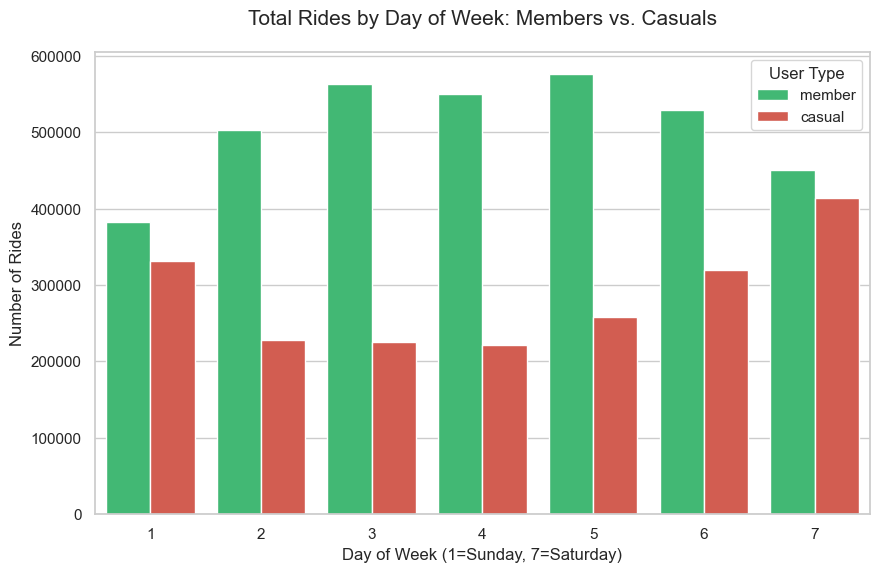

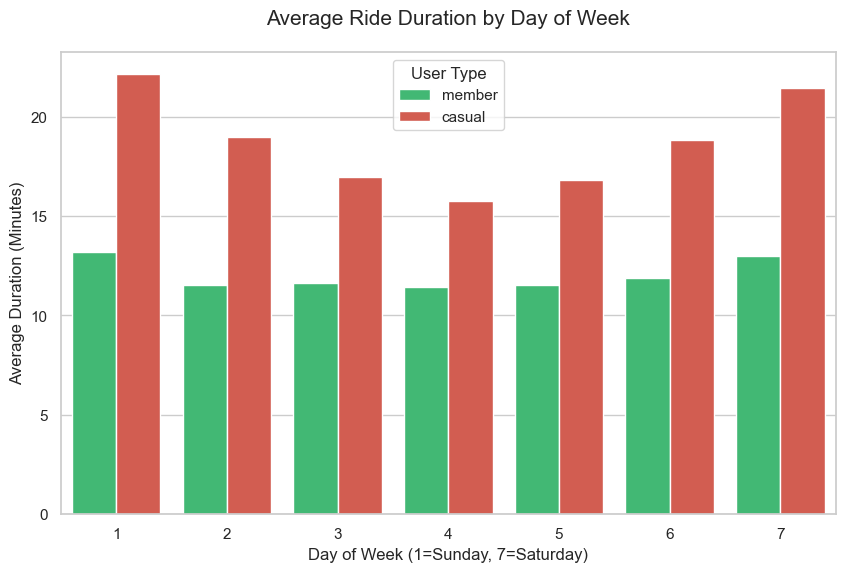

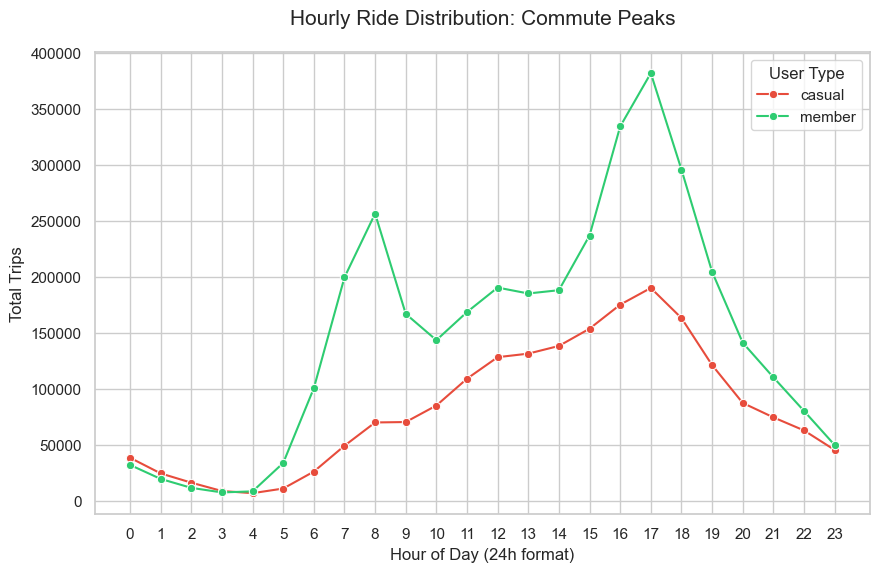

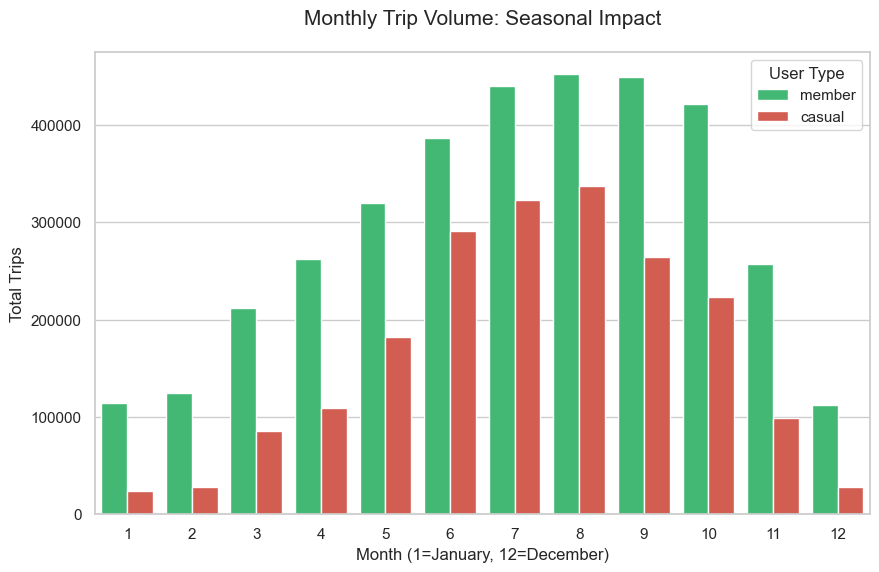

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aesthetic settings for "polished" charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]
palette = {"member": "#2ecc71", "casual": "#e74c3c"} # Verde para membros, Vermelho para casuais

# --- 1. Total Rides by Day of Week ---
plt.figure()
sns.countplot(data=annual_df, x='day_of_week', hue='member_casual', palette=palette)
plt.title('Total Rides by Day of Week: Members vs. Casuals', fontsize=15, pad=20)
plt.xlabel('Day of Week (1=Sunday, 7=Saturday)', fontsize=12)
plt.ylabel('Number of Rides', fontsize=12)
plt.legend(title='User Type')
plt.show()

# --- 2. Average Ride Duration by Day of Week ---
plt.figure()
sns.barplot(data=annual_df, x='day_of_week', y='ride_length', hue='member_casual', palette=palette, errorbar=None)
plt.title('Average Ride Duration by Day of Week', fontsize=15, pad=20)
plt.xlabel('Day of Week (1=Sunday, 7=Saturday)', fontsize=12)
plt.ylabel('Average Duration (Minutes)', fontsize=12)
plt.legend(title='User Type')
plt.show()

# --- 3. Hourly Distribution of Trips (Commuter Patterns) ---
hourly_counts = annual_df.groupby(['hour', 'member_casual']).size().reset_index(name='trip_count')
plt.figure()
sns.lineplot(data=hourly_counts, x='hour', y='trip_count', hue='member_casual', palette=palette, marker='o')
plt.title('Hourly Ride Distribution: Commute Peaks', fontsize=15, pad=20)
plt.xlabel('Hour of Day (24h format)', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.xticks(range(0, 24))
plt.legend(title='User Type')
plt.show()

# --- 4. Monthly Usage Trends (Seasonality) ---
plt.figure()
sns.countplot(data=annual_df, x='month', hue='member_casual', palette=palette)
plt.title('Monthly Trip Volume: Seasonal Impact', fontsize=15, pad=20)
plt.xlabel('Month (1=January, 12=December)', fontsize=12)
plt.ylabel('Total Trips', fontsize=12)
plt.legend(title='User Type')
plt.show()

In [7]:
# # Phase 6: Act - Recommendations and Conclusion

# ## Final Conclusion
# The analysis confirms that while Annual Members use Cyclistic as a reliable functional tool for daily commuting, Casual Riders view it primarily as a recreational weekend luxury. The key to growth lies not in changing the casual riders' weekend habits, but in demonstrating how Cyclistic can fulfill their weekday transportation needs.

# ## Top Three Recommendations

# ### 1. Targeted "Commuter-Trial" Membership
# The Data: Members show significant peaks at 8 AM and 5 PM, while many casual riders also use the bikes during these hours but only sporadically.
# Action: Launch a "Commuter Conversion" promotion. Offer casual riders who record more than two trips during weekday rush hours a discounted 3-month trial of the annual membership. This lowers the barrier to entry and allows them to experience the cost-benefit of a membership for work/school trips.

# ### 2. Seasonal Weekend-to-Member Campaign
# The Data: Casual ridership peaks in the summer, especially on weekends.
# Action: Implement an "Upgrade Your Summer" campaign. Use digital marketing and physical signage at high-traffic weekend stations (parks and tourist spots) to offer a limited-time credit. Casual riders can apply the cost of their weekend single-ride passes toward the purchase of an annual membership if they upgrade within 48 hours.

# ### 3. Digital Engagement for Leisure Users
# The Data: Casual trips are significantly longer in duration, indicating leisure use.
# Action: Enhance the Cyclistic app to include "Member-Only" features such as curated leisure routes, partnership discounts at local cafes near popular stations, and fitness tracking. By adding "lifestyle" value to the membership beyond just the price of the ride, casual riders will have more incentive to join the community permanently.

# ## Next Steps for Stakeholders
# A/B Testing: Run a pilot for the "Commuter-Trial" in specific high-traffic areas of Chicago.
# Additional Data: I recommend collecting data on user proximity to docking stations and home/work locations to further refine the marketing reach for the annual plan.